# Get data

In [1]:
from influxdb_client import InfluxDBClient
from influxdb_client.client.write_api import SYNCHRONOUS
import pandas as pd

def load_and_save_from_influxdb(bucket: str):
    # Replace these with your InfluxDB token, organization, and bucket
    org = "ur3e"
    token = "qFEMOoL0ghl90ghWnzq61MNfoI20_cZrAffwooMdgUl8tk-eIUVsI4Vv7vCsLR9eCeLPPWGYNemWblSlzv3WSw=="

    # Initialize the client
    client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
    write_api = client.write_api(write_options=SYNCHRONOUS)   
    query_api = client.query_api()

    time_start = "-1000h"
    time_stop = "now()"

    # Get sensor data
    query_sensor_data = f'''
        from(bucket: "{bucket}")
        |> range(start: {time_start}, stop: {time_stop})
        |> filter(fn: (r) => r["_measurement"] == "robotarm.pt.state")
        |> filter(fn: (r) => r["_field"] =~ /(((q_actual|qd_actual|q_target)_[0-6])|(tcp_pose_[0-6]))/)
        |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
        '''

    df_sensor_data = query_api.query_data_frame(query_sensor_data)

    # Get wear injections
    query_wear_injections = f'''
        from(bucket: "{bucket}")
        |> range(start: {time_start}, stop: {time_stop})
        |> filter(fn: (r) => r["_measurement"] == "robotarm.ctrl")
        |> filter(fn: (r) => r["_field"] =~ /joints_0/)
        |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
        '''

    df_wear_injections = query_api.query_data_frame(query_wear_injections)

    # Remove unwanted columns
    cols_to_exclude = ["result", "table", "_start", "_stop", "_measurement", "msg_type"]
    df_filtered_sensor_data = df_sensor_data.drop(columns=cols_to_exclude)
    df_filtered_wear_injections = df_wear_injections.drop(columns=["result", "table", "_start", "_stop", "_measurement", "msg_type"])

    # Construct labeled dataframe
    # 1. Ensure time columns are datetime objects 
    df_filtered_wear_injections['_time'] = pd.to_datetime(df_filtered_wear_injections['_time'])
    df_filtered_sensor_data['_time'] = pd.to_datetime(df_filtered_sensor_data['_time'])

    # 2. Extract both the timestamps AND the joint numbers into lists
    reference_timestamps = df_filtered_wear_injections['_time'].tolist()
    joint_numbers = df_filtered_wear_injections['joints_0'].tolist()

    # 3. Reorder in terms of joint_numbers
    # Zip pairs them up: (joint, time), sorts by the first element (joint), then unzips
    sorted_pairs = sorted(zip(joint_numbers, reference_timestamps))
    joint_numbers, reference_timestamps = map(list, zip(*sorted_pairs))

    # 4. Use zip() to loop through both lists at the same time
    for ref_time, joint_num in zip(reference_timestamps, joint_numbers):
        # Name the column using the exact joint number (e.g., after_injection_1)
        col_name = f'joint_{joint_num}_worn'
        
        # Apply the binary comparison logic
        df_filtered_sensor_data[col_name] = (df_filtered_sensor_data['_time'] > ref_time).astype(int)

    # Remove timestamps for all dataframes
    df_filtered_sensor_data = df_filtered_sensor_data.drop(columns=["_time"])

    # ==== SAVE THE DATAFRAME ====

    # 1. Define the directory and create it if it doesn't exist
    output_dir = Path("./data")
    output_dir.mkdir(parents=True, exist_ok=True)

    # 2. Save the Training sets
    # Creates a path like: ./data/train_scaled_0.csv
    file_path = output_dir / f"{bucket}.csv" 
    df_filtered_sensor_data.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    return df_filtered_sensor_data

def load_data_bucket(bucket: str) -> pd.DataFrame:
    # Check if the file already exists
    file_path = Path(f"./data/{bucket}.csv")
    if file_path.exists():
        print(f"Loading existing file: {file_path}")
        return pd.read_csv(file_path)
    else:
        print(f"File not found: {file_path}. Fetching from InfluxDB...")
        return load_and_save_from_influxdb(bucket)

In [2]:
from pathlib import Path

# Put all dataframes from InfluxDB into lists
train_dfs = []
for i in range(1, 7):
    try:
        train_dfs.append(load_data_bucket(f"train_data_{i}"))
    except:
        print(f"Failed to fetch train_data_{i}")

test_dfs = []
for i in range(1, 7):
    try:
        test_dfs.append(load_data_bucket(f"test_data_{i}"))
    except:
        print(f"Failed to fetch test_data_{i}")


Loading existing file: data/train_data_1.csv
Loading existing file: data/train_data_2.csv
Loading existing file: data/train_data_3.csv
Loading existing file: data/train_data_4.csv
Loading existing file: data/train_data_5.csv
Loading existing file: data/train_data_6.csv
Loading existing file: data/test_data_1.csv
Loading existing file: data/test_data_2.csv
Loading existing file: data/test_data_3.csv
Loading existing file: data/test_data_4.csv
Loading existing file: data/test_data_5.csv
Loading existing file: data/test_data_6.csv


# Preprocess data

In [3]:
import roboticstoolbox as rtb
import numpy as np

# Load the standard UR3e DH parameters once globally
link1 = rtb.RevoluteDH(d=0.15185, a=0.0,      alpha=np.pi / 2)
link2 = rtb.RevoluteDH(d=0.0,     a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0,     a=-0.2132,  alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0,      alpha=np.pi / 2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0,      alpha=-np.pi / 2)
link6 = rtb.RevoluteDH(d=0.0921,  a=0.0,      alpha=0.0)
robot = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

def replace_tcp_with_deviation(df):
    """
    Calculates TCP deviation, drops raw tcp_pose columns, adds the deviation 
    as a feature, and ensures the 6 labels stay at the very end.
    """
    df_processed = df.copy()
    n_samples = len(df_processed)
    
    # 1. Extract joints and measured TCP
    q_actual = df_processed[[f'q_actual_{i}' for i in range(6)]].to_numpy()
    tcp_measured = df_processed[[f'tcp_pose_{i}' for i in range(3)]].to_numpy()
    
    # 2. Calculate Theoretical TCP using Forward Kinematics
    tcp_theoretical = np.zeros((n_samples, 3))
    for j in range(n_samples):
        tcp_theoretical[j, :] = robot.fkine(q_actual[j, :]).t
        
    # 3. Calculate the Error Magnitude (in mm)
    tcp_error_vector_mm = (tcp_theoretical - tcp_measured) * 1000
    
    # 4. Drop the old tcp_pose columns (X, Y, Z, Rx, Ry, Rz)
    cols_to_drop = [f'tcp_pose_{i}' for i in range(6)]
    # Filter to only drop columns that actually exist in the dataframe
    cols_to_drop = [c for c in cols_to_drop if c in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    # 5. Isolate feature columns and label columns
    label_cols = [c for c in df_processed.columns if 'worn' in c]
    feature_cols = [c for c in df_processed.columns if c not in label_cols]
    
    # Add the new directional features
    df_processed['tcp_dev_x_mm'] = tcp_error_vector_mm[:, 0]
    df_processed['tcp_dev_y_mm'] = tcp_error_vector_mm[:, 1]
    df_processed['tcp_dev_z_mm'] = tcp_error_vector_mm[:, 2]

    # 6. Add the new deviation feature and reorder
    df_processed['tcp_deviation_mm'] = np.linalg.norm(tcp_error_vector_mm, axis=1)
    
    # Reconstruct the dataframe: [All Features] + [TCP Deviation] + [6 Labels]
    final_columns = feature_cols + ['tcp_dev_x_mm', 'tcp_dev_y_mm', 'tcp_dev_z_mm', 'tcp_deviation_mm'] + label_cols
    
    return df_processed[final_columns]

In [4]:
def replace_joints_with_residuals(df):
    """
    Takes a dataframe, calculates joint tracking errors (target - actual),
    drops the raw actual and target columns, and returns the processed dataframe.
    """
    df_processed = df.copy()
    
    # 1. Calculate Joint Tracking Errors (Residuals)
    for i in range(6):
        # Positional Error
        df_processed[f'q_error_{i}'] = df_processed[f'q_target_{i}'] - df_processed[f'q_actual_{i}']
        
    # 2. Compile a list of all raw columns to drop
    cols_to_drop = []
    cols_to_drop += [f'q_actual_{i}' for i in range(6)]
    cols_to_drop += [f'q_target_{i}' for i in range(6)]

    # Filter to only drop columns that actually exist in the dataframe
    cols_to_drop = [c for c in cols_to_drop if c in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    # 3. Isolate feature columns and label columns to ensure labels stay at the end
    label_cols = [c for c in df_processed.columns if 'worn' in c]
    feature_cols = [c for c in df_processed.columns if c not in label_cols]
    
    # 4. Reconstruct and return the dataframe
    final_columns = feature_cols + label_cols
    
    return df_processed[final_columns]

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Print a quick status update since FK takes a bit of time to compute
print("Calculating TCP Deviations for Training Data...")
train_dfs = [replace_joints_with_residuals(replace_tcp_with_deviation(df)) for df in train_dfs]

print("Calculating TCP Deviations for Testing Data...")
test_dfs = [replace_joints_with_residuals(replace_tcp_with_deviation(df)) for df in test_dfs]

# Now proceed with your scaling exactly as before
train_data_combined = pd.concat(train_dfs)
feature_cols = train_data_combined.columns[:-6]

# Fit scaler ONLY on the training features
scaler = StandardScaler()
scaler.fit(train_data_combined[feature_cols])

def scale_features(df):
    """Helper to scale features but leave binary targets untouched."""
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.transform(df[feature_cols])
    return df_scaled

# Apply to datasets
train_dfs_scaled = [scale_features(df) for df in train_dfs]
test_dfs_scaled = [scale_features(df) for df in test_dfs]

Calculating TCP Deviations for Training Data...
Calculating TCP Deviations for Testing Data...


In [112]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MultiSeriesDataset(Dataset):
    def __init__(self, dataframes, seq_length):
        """
        Args:
            dataframes (list of pd.DataFrame): List of independent time-series dataframes.
            seq_length (int): How many past time steps to use as input (X).
        """
        self.seq_length = seq_length
        
        # We convert once to PyTorch tensors and keep them in a list.
        # No sliding windows are created here, saving massive amounts of RAM.
        self.data = [torch.tensor(df.values, dtype=torch.float32) for df in dataframes]
        
        # Instead of storing GBs of overlapping floats, we store a tiny list of tuples:
        # (dataframe_index, window_start_index)
        self.index_map = []
        
        for df_idx, series in enumerate(self.data):
            # Calculate how many valid windows can be pulled from this dataframe
            num_windows = len(series) - self.seq_length
            
            if num_windows > 0:
                # Store the coordinates to fetch the window later
                for start_idx in range(num_windows):
                    self.index_map.append((df_idx, start_idx))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        # 3. Generate the window ON THE FLY
        df_idx, start_idx = self.index_map[idx]
        
        # Fetch the specific dataframe tensor
        series = self.data[df_idx]
        
        # Slice X: The sequence of past observations (excluding last 6 columns)
        window_x = series[start_idx : start_idx + self.seq_length, :-6]
        
        # Slice y: The target values at the next time step (the last 6 columns)
        window_y = series[start_idx + self.seq_length, -6:]

        return window_x, window_y

In [113]:
# Declare datasets
train_ds = MultiSeriesDataset(train_dfs_scaled, 100)
test_ds = MultiSeriesDataset(test_dfs_scaled, 100)

# Declare dataloaders
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=16, shuffle=False)

In [190]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_size=16, hidden_size=64, num_layers=1, output_size=6):
        super().__init__()
        # batch_first=True means the network expects tensors shaped like: 
        # [batch_size, sequence_length, input_size]
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True
        )
        self.dropout = nn.Dropout(p=0.4)
        
        # MLP for mapping hidden state to 6 joint wear predictions
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x in R^[batch_size, seq_length, 19]
        
        # Pass the sequence through the LSTM
        # lstm_out contains the output features from every time step in the sequence.
        # h_n and c_n are the final hidden and cell states (we don't need them for this pass).
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Pass that final time step's data through the linear layer to get the 6 outputs
        out = self.dropout(lstm_out[:, -1, :])
        prediction = self.fc(out)
        
        # predictions shape coming out: [batch_size, 6]
        return prediction

In [ ]:
import torch
import torch.nn as nn

class Chomp1d(nn.Module):
    """
    Removes the extra padding on the right side of the sequence.
    This ensures the convolution is strictly 'causal' (no looking into the future).
    """
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.3):
        super(TemporalBlock, self).__init__()
        
        # Layer 1
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, 
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # Layer 2
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, 
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        
        # Residual connection: If the number of channels changes, we use a 1x1 conv to match them up
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        # Add the original input to the output (Residual connection)
        return self.relu(out + res)

class TCN_Net(nn.Module):
    def __init__(self, input_size=16, num_channels=[32, 64, 128], kernel_size=3, dropout=0.3, output_size=6):
        """
        num_channels: A list detailing the number of filters in each layer. 
                      Length of the list dictates the number of layers.
        """
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i  # Dilations scale exponentially: 1, 2, 4, 8...
            in_channels = input_size if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, 
                                     dilation=dilation_size, 
                                     padding=(kernel_size-1) * dilation_size, 
                                     dropout=dropout)]

        self.tcn = nn.Sequential(*layers)
        
        # Final fully connected layer mapping the highest channel output to the 6 joints
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # x comes in as: [batch_size, seq_length, input_size]
        # However, nn.Conv1d expects: [batch_size, channels/features, seq_length]
        x = x.transpose(1, 2)
        
        # Pass through the Temporal Convolutional blocks
        # y shape: [batch_size, last_layer_channels, seq_length]
        y = self.tcn(x) 
        
        # We only care about the network's understanding at the very FINAL time step
        # This final step contains the accumulated context of the entire sequence
        last_step_features = y[:, :, -1] # shape: [batch_size, last_layer_channels]
        
        # Pass to the linear classifier
        prediction = self.fc(last_step_features)
        
        # Output shape: [batch_size, 6]
        return prediction

In [191]:
def train(model, train_loader, optim, loss_fn):
    model.train()
    running_loss = 0
    total_predictions = 0
    for x, y in train_loader:
        # Reset gradients
        optim.zero_grad()
        # Make prediction by model
        pred = model(x)
        # Calc loss gradient
        loss = loss_fn(pred, y)
        loss.backward()
        # Optimize model
        optim.step()

        # Gather loss
        running_loss += loss.item() * x.size(0) 
        total_predictions += x.size(0) # Count samples, not total elements
        
    mean_loss = running_loss / total_predictions if total_predictions > 0 else 0
    return mean_loss

def test(model, test_loader, loss_fn):
    model.eval()
    running_loss = 0
    
    correct_predictions = 0
    correct_joint_predictions = torch.zeros((6))
    total_timesteps = 0  # Used for accuracy
    total_elements = 0   # Used to keep your loss calculation consistent
    
    with torch.no_grad():
        for x, y in test_loader:
            pred = model(x)
            loss = loss_fn(pred, y)

            # Accuracy calculation
            pred_labels = (pred > 0).float() # same as nn.functional.sigmoid(pred) > 0.5
            
            # .all(dim=-1) checks the last dimension (the 6 joints). 
            # It returns True ONLY if all 6 predictions match the targets for that timestep.
            correct_at_timestep = (pred_labels == y)
            correct_at_timestep_global = correct_at_timestep.all(dim=-1)
            
            # Sum up the fully correct timesteps
            correct_predictions += correct_at_timestep_global.sum().item()
            correct_joint_predictions += correct_at_timestep.sum(dim=(0))
            # Count total number of timesteps evaluated (batch_size * sequence_length)
            total_timesteps += correct_at_timestep_global.numel()

            # Update loss
            running_loss += loss.item() * x.size(0)
            total_elements += x.size(0) 
            
        # Calculate overall accuracy based on exact-match timesteps
        accuracy = correct_predictions / total_timesteps if total_timesteps > 0 else 0
        joint_accuracies = correct_joint_predictions / total_timesteps if total_timesteps > 0 else 0
        
        # Calculate loss exactly as you had it before
        mean_loss = running_loss / total_elements if total_elements > 0 else 0
        
    return mean_loss, accuracy, joint_accuracies

In [200]:
# Custom focal loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        # gamma controls how heavily we penalize "easy" examples. 
        # 2.0 is the standard default from the original paper.
        self.gamma = gamma

    def forward(self, inputs, targets):
        # 1. Compute standard BCE loss with logits (numerically stable)
        # We use reduction='none' so we get the loss for every individual prediction
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # 2. Calculate pt (the model's probability of the TRUE class)
        # Neat math trick: Since BCE = -log(pt), then exp(-BCE) = pt
        pt = torch.exp(-bce_loss)
        
        # 3. Calculate the Focal weighting term: (1 - pt)^gamma
        focal_weight = (1 - pt) ** self.gamma
        
        # 4. Apply the weight to the original loss and take the mean
        focal_loss = focal_weight * bce_loss
        
        return focal_loss.mean()

In [201]:
# Prepare for training
import torch
model = Net()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001, weight_decay=0.0001)
loss_fn = FocalLoss()
# loss_fn = nn.BCEWithLogitsLoss() # pos_weight makes false positives be punished more than false negatives

train_loss, test_loss, test_accuracies, test_joint_accuracies = [], [], [], []

In [202]:
# Train
epochs = 100
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    trl = train(model, train_loader, optimizer, loss_fn)
    train_loss.append(trl)
    tel, test_accuracy, test_joint_accuracy = test(model, test_loader, loss_fn)
    test_loss.append(tel)
    test_accuracies.append(test_accuracy)
    test_joint_accuracies.append(test_joint_accuracy)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100


KeyboardInterrupt: 

tensor([0.6135, 0.8205, 0.8846, 0.7484, 0.7570, 0.5988])


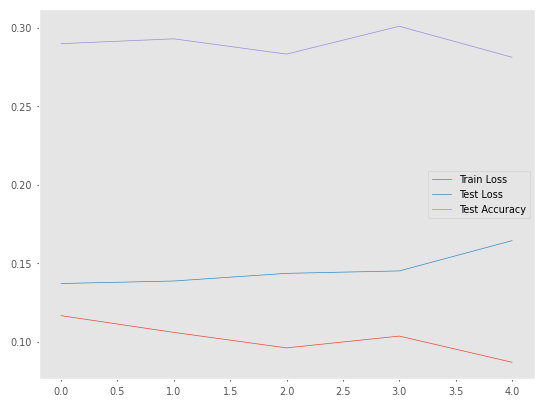

In [203]:
import matplotlib.pyplot as plt

plt.plot(np.array(train_loss), label="Train Loss")
plt.plot(np.array(test_loss), label="Test Loss")
plt.plot(test_accuracies, label="Test Accuracy")
plt.grid()
plt.legend()

print(test_joint_accuracies[-1])

In [210]:
a = 6000

illustration_df = test_dfs[0][a:a+100]

# Using .float() to cast the tensor to float32
data = torch.tensor(illustration_df.to_numpy()[:, :-6]).float().unsqueeze(0)


model_output = nn.functional.sigmoid(model(data).squeeze())

model_output_rounded = (model_output.detach().numpy() > 0.5).astype(np.float32)

print(model_output_rounded.shape)

(6,)


All joint ground truths: [1. 0. 0. 0. 0. 0.]
All joint predictions: [1. 1. 1. 1. 1. 1.]


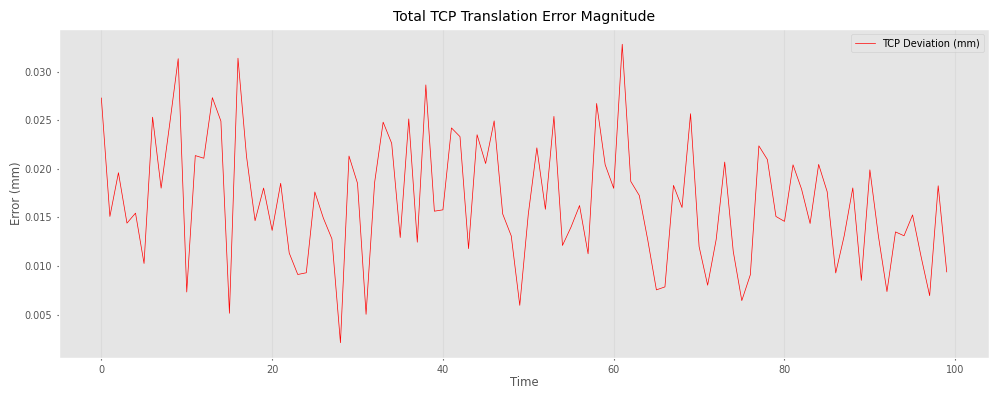

In [211]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

n_samples = len(illustration_df.to_numpy()[:, 0])

# 3. Extract Measured TCP Translation (Assuming indices 0, 1, 2 are X, Y, Z)
tcp_error_mm = illustration_df["tcp_deviation_mm"].to_numpy()

joint_worn = np.zeros((n_samples, 6))
for i in range(6):
    joint_worn[:, i] = illustration_df[f"joint_{i+1}_worn"].to_numpy()

# 6. Plotting
plt.figure(figsize=(10, 4))

# Subplot 2: Total TCP Error
plt.plot(tcp_error_mm, label="TCP Deviation (mm)", color="red")
plt.title("Total TCP Translation Error Magnitude")
plt.ylabel("Error (mm)")
plt.xlabel("Time")
plt.grid(axis="y")
plt.legend()

# Plot all joint wear predictions
print(f"All joint ground truths: {illustration_df.to_numpy()[-1, -6:]}")
print(f"All joint predictions: {model_output_rounded}")



plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model
torch.save(model.state_dict(), "wear_localization_model_TCP_Deviation_XYZ.pth")

In [ ]:
# Load the saved model 
model = Net()
model.load_state_dict(torch.load("wear_localization_model.pth"))

In [ ]:
# Final model evaluation
test(model, train_loader, loss_fn), test(model, test_loader, loss_fn)

((3.918270453076175e-05,
  0.0020551326172350264,
  tensor([0.0862, 0.0884, 0.1010, 0.0622, 0.0776, 0.0804])),
 (3.91864195317997e-05,
  0.002183102724273288,
  tensor([0.0867, 0.0894, 0.0993, 0.0635, 0.0776, 0.0794])))